# Scanpy PBMC3k preprocessing 예제

이 노트북은 `pbmc3k` 데이터를 기준으로 다음 흐름을 확인하는 예제입니다.

1. 데이터 로드  
2. QC metric 계산  
3. Cell/gene filtering  
4. Count layer 보존  
5. Normalization / log transform  
6. HVG 선택  
7. PCA / neighbor graph / UMAP  
8. Leiden clustering  
9. Marker 기반 cluster 확인  
10. CellTypist 기반 자동 annotation

> 실제 데이터에 적용할 때는 QC cutoff, HVG 수, PCA 차원 수, clustering resolution을 데이터 특성에 맞게 다시 조정해야 합니다.

## 1. 기본 패키지 설치 및 로드

In [1]:
!pip install scanpy
!pip install igraph
!pip install leidenalg
!pip install celltypist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.

In [2]:
import scanpy as sc
import matplotlib.pyplot as plt

# 그림 기본 해상도 설정
sc.set_figure_params(dpi=100, facecolor="white")

## 2. 예제 데이터 로드

`pbmc3k`는 10x Genomics human PBMC 3k 예제 데이터입니다.  

In [3]:
adata = sc.datasets.pbmc3k()
adata

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

### Raw count 일부 확인

In [4]:
# sparse matrix이므로 일부만 dense array로 변환해서 확인
adata.X[:3, :100].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.

## 3. QC metric 계산

QC에 사용할 gene group을 먼저 정의합니다.

- `mt`: mitochondrial genes
- `ribo`: ribosomal genes
- `hb`: hemoglobin genes

주의할 점은 species마다 mitochondrial prefix가 다릅니다.

- Human: `MT-`
- Mouse: `mt-` 또는 annotation에 따라 `Mt-`

In [5]:
# mitochondrial genes: human PBMC 기준
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [6]:
adata.var.head()

,gene_ids,mt,ribo,hb
index,,,,
MIR1302-10,ENSG00000243485,False,False,False
FAM138A,ENSG00000237613,False,False,False
OR4F5,ENSG00000186092,False,False,False
RP11-34P13.7,ENSG00000238009,False,False,False
RP11-34P13.8,ENSG00000239945,False,False,False
...,...,...,...,...
AC145205.1,ENSG00000215635,False,False,False
BAGE5,ENSG00000268590,False,False,False
CU459201.1,ENSG00000251180,False,False,False


In [7]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    log1p=True,
)

In [8]:
adata.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
index,,,,,,,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283,1057.0,6.964136,43.659645,0.0,0.0,0.0
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596,2079.0,7.640123,42.402611,0.0,0.0,0.0
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171,997.0,6.905753,31.660847,0.0,0.0,0.0
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850148,1.743085,640.0,6.463029,24.251610,0.0,0.0,0.0
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242,146.0,4.990433,14.882773,0.0,0.0,0.0


## 4. QC plot 확인

아래 plot은 cutoff를 정하기 위한 진단용입니다.  
이 예제에서는 최소 gene/cell 기준만 적용하고, mitochondrial percent 기준 filtering은 직접 적용하지 않았습니다.

실제 분석에서는 보통 다음 항목을 같이 봅니다.

- `n_genes_by_counts`: cell별 검출 gene 수
- `total_counts`: cell별 UMI/count 수
- `pct_counts_mt`: mitochondrial count 비율

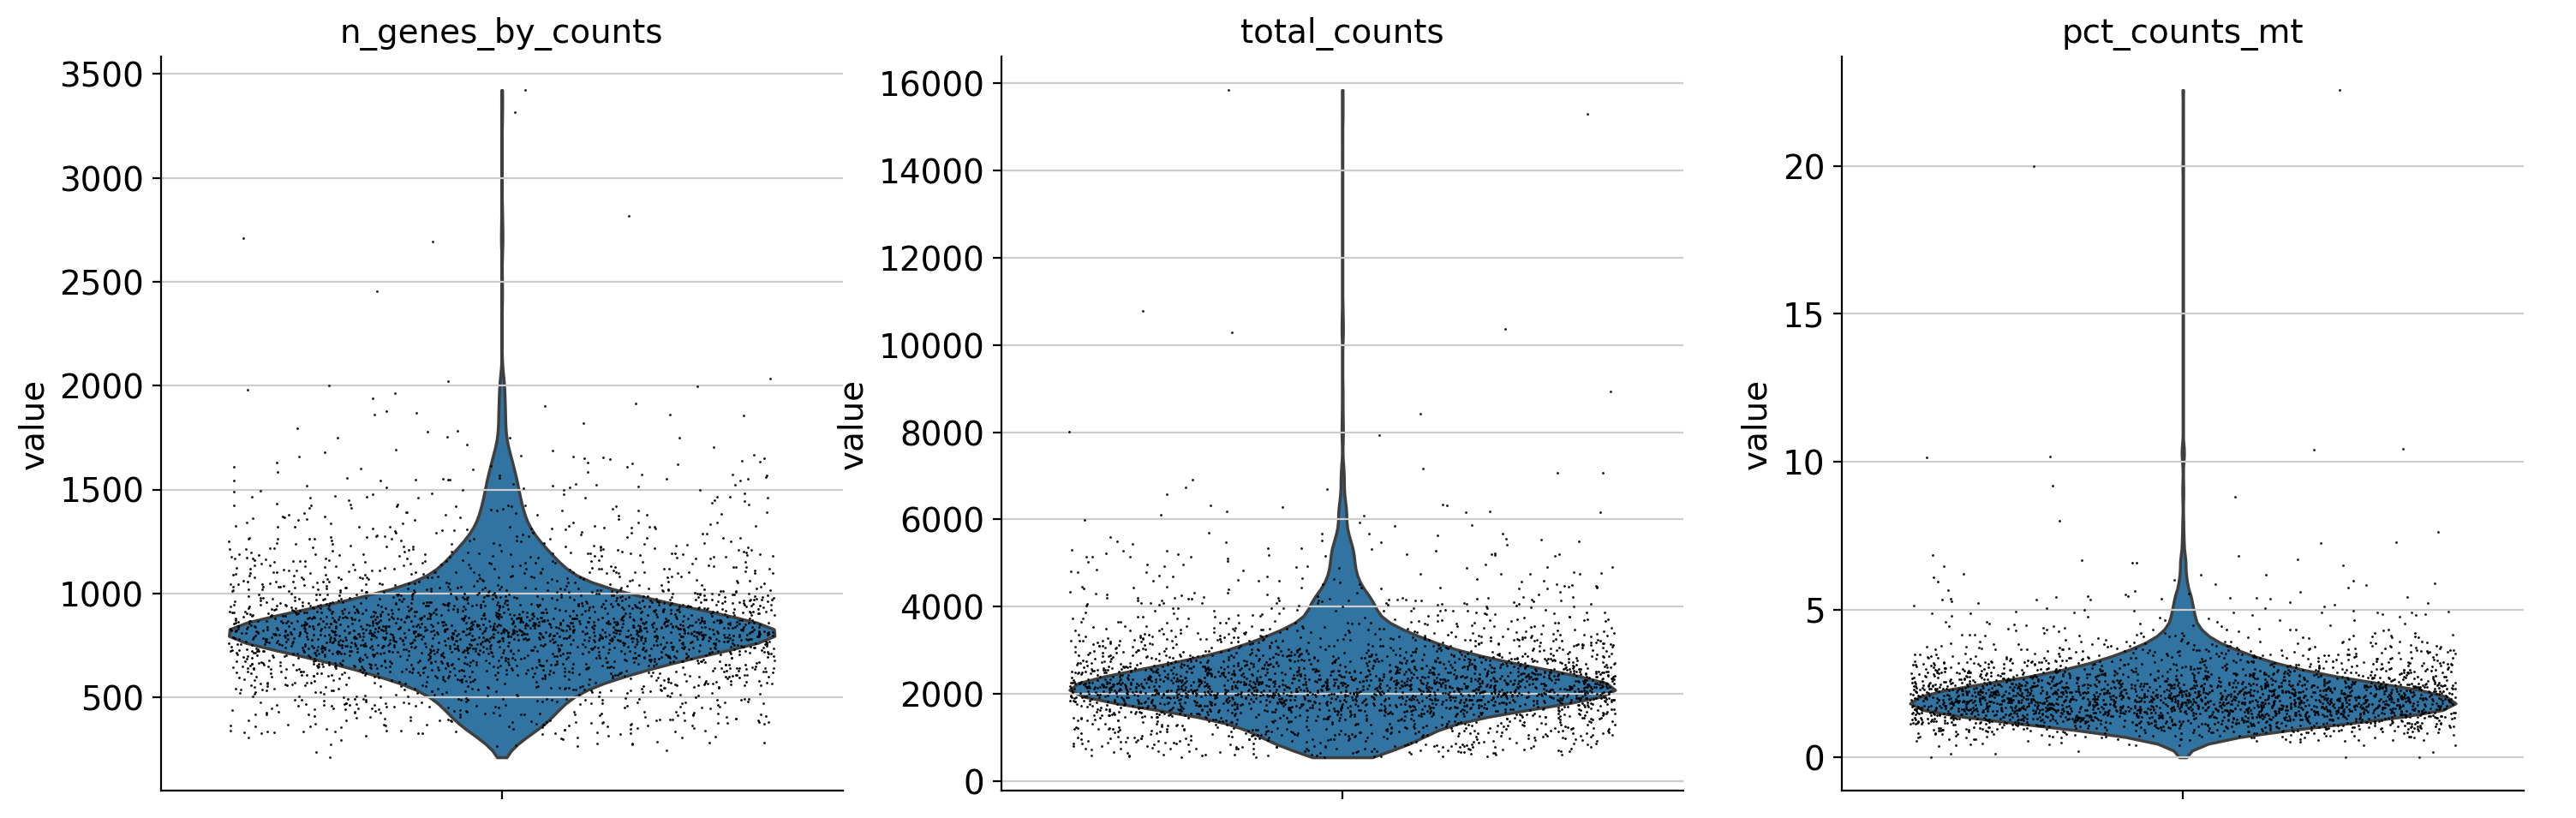

In [9]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

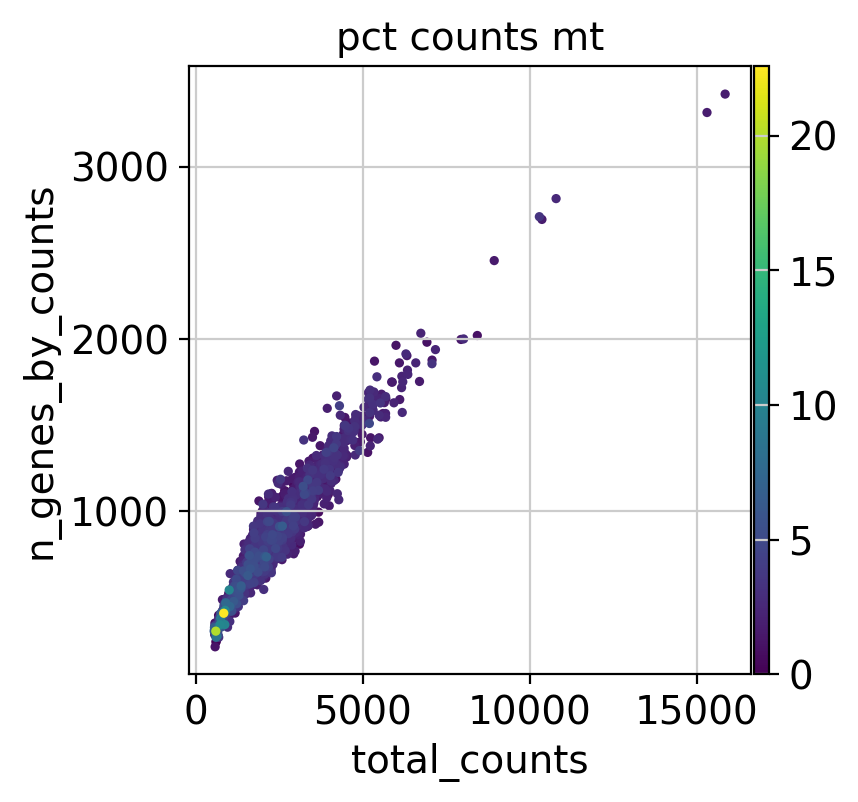

In [10]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
)

## 5. 기본 filtering

여기서는 tutorial 수준의 최소 filtering만 적용합니다.

- cell: 최소 200개 gene 이상 검출
- gene: 최소 3개 cell 이상에서 검출

> 분석용 데이터에서는 `pct_counts_mt`, doublet score, sample별 depth 차이 등을 함께 고려하는 것이 안전합니다.

In [11]:
# Low-quality cell 제거
sc.pp.filter_cells(adata, min_genes=200)

# 거의 검출되지 않는 gene 제거
sc.pp.filter_genes(adata, min_cells=3)

adata

AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

## 6. Raw count layer 보존

Normalization 이후에도 raw count가 필요한 경우가 많습니다.  
예를 들어 CellTypist, DEG, pseudobulk, raw count 기반 모델 입력 등에서 원본 count가 필요할 수 있습니다.

In [12]:
# log-normalization 전에 count matrix를 layer에 저장
adata.layers["counts"] = adata.X.copy()

## 7. Normalization 및 log transform

Scanpy 기본 tutorial 흐름입니다.

1. Cell별 total count를 `1e4`로 맞춤
2. `log1p` 변환

In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [14]:
# log-normalized value 일부 확인
adata.X[:5, :100].toarray()

array([[0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 1.6358733,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 1.6358733, 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 2.226554

## 8. Highly variable genes 선택

HVG는 PCA, neighbor graph, UMAP, clustering에 사용할 feature를 줄이는 단계입니다.  
여기서는 상위 2,000개 gene을 사용합니다.

In [15]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
)

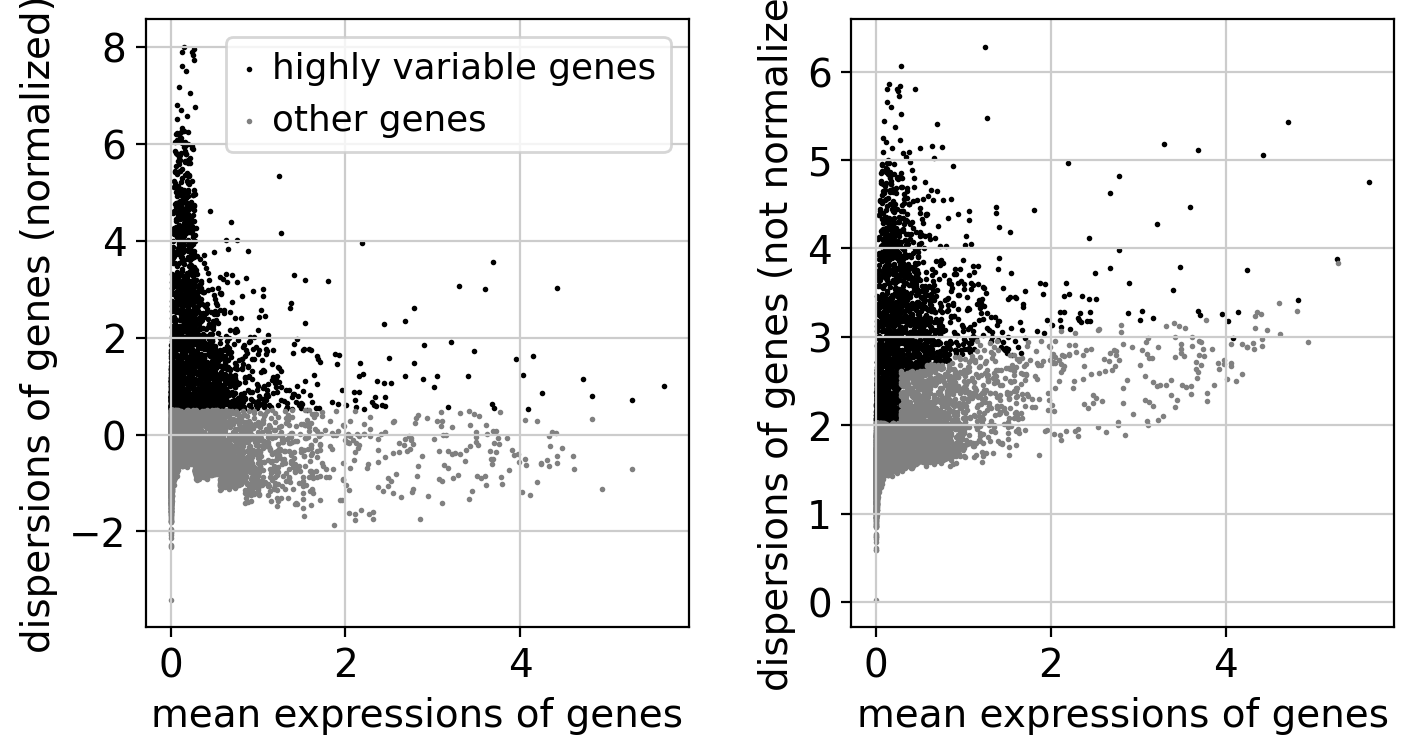

In [16]:
sc.pl.highly_variable_genes(adata)

## 9. PCA

HVG 기반으로 차원을 축소합니다.  
이후 neighbor graph와 UMAP은 PCA space를 기반으로 계산합니다.

In [17]:
sc.tl.pca(adata)

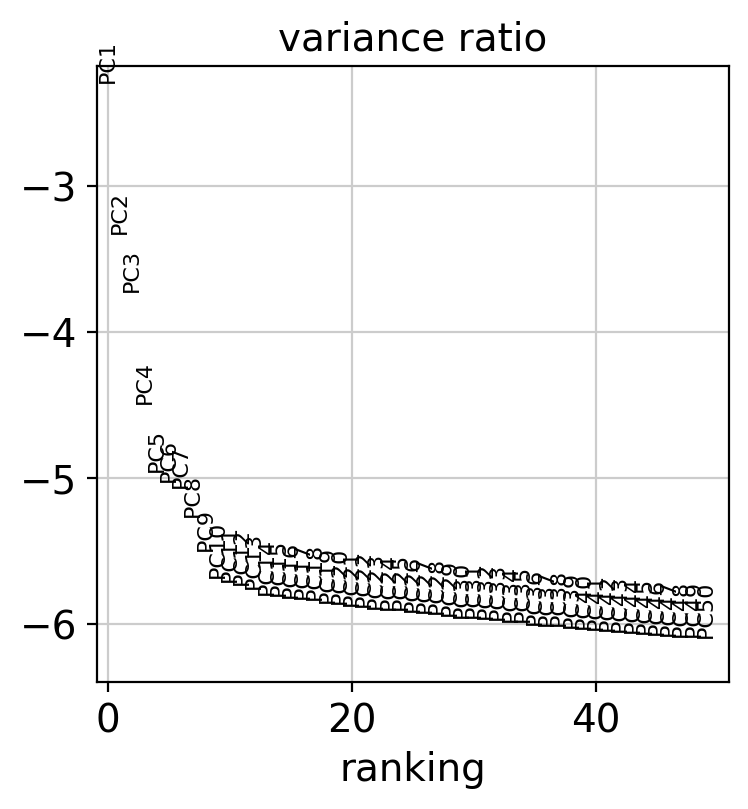

In [18]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

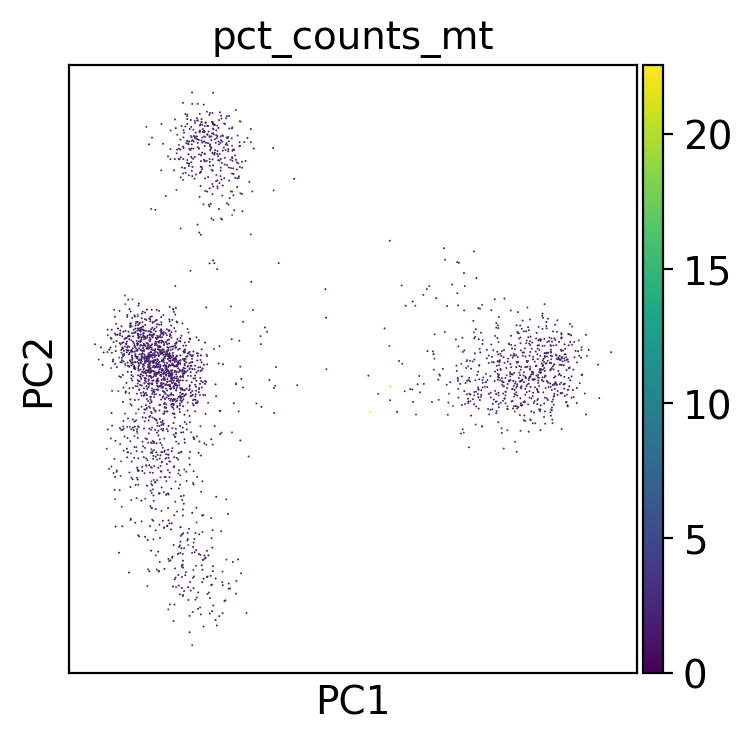

In [19]:
sc.pl.pca(
    adata,
    color=["pct_counts_mt"],
    dimensions=[(0, 1)],
    ncols=2,
    size=2,
)

## 10. Neighbor graph 및 UMAP

- `n_neighbors`: local neighborhood 크기
- `n_pcs`: 사용할 PCA 차원 수

이 값들은 UMAP 구조와 clustering 결과에 직접 영향을 줍니다.

In [20]:
sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=20,
)

In [38]:
sc.tl.umap(adata,random_state=42)

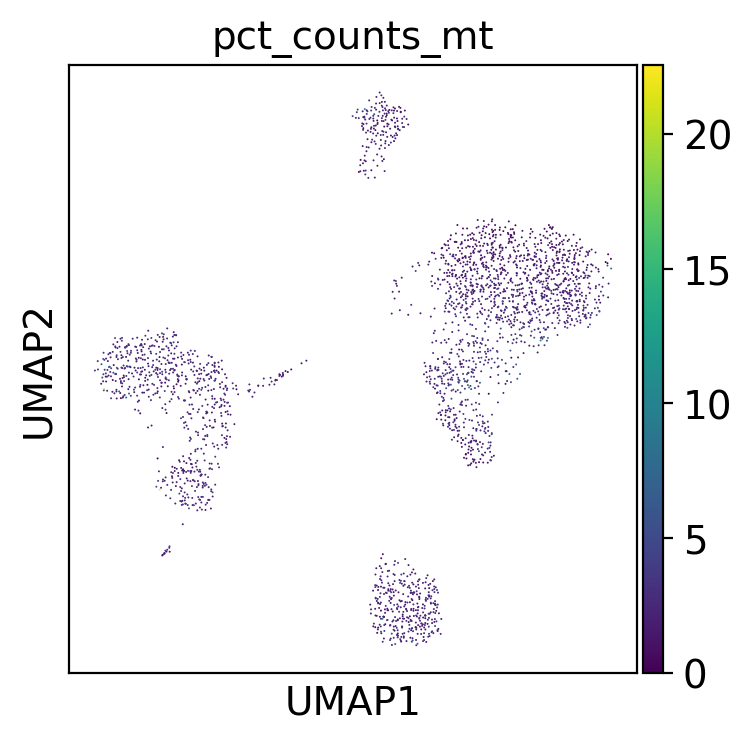

In [39]:
sc.pl.umap(
    adata,
    color="pct_counts_mt",
    size=2,  # point overlap 완화
)

## 11. Leiden clustering

`leidenalg`와 `igraph`가 설치되어 있지 않다면 아래 설치 셀을 한 번 실행합니다.  
이미 설치되어 있다면 건너뛰어도 됩니다.

In [42]:
# igraph backend와 고정 random_state를 사용해 재현성을 확보
sc.tl.leiden(
    adata,
    resolution=0.4,
    random_state=42,
    n_iterations=2,
    directed=False,
)

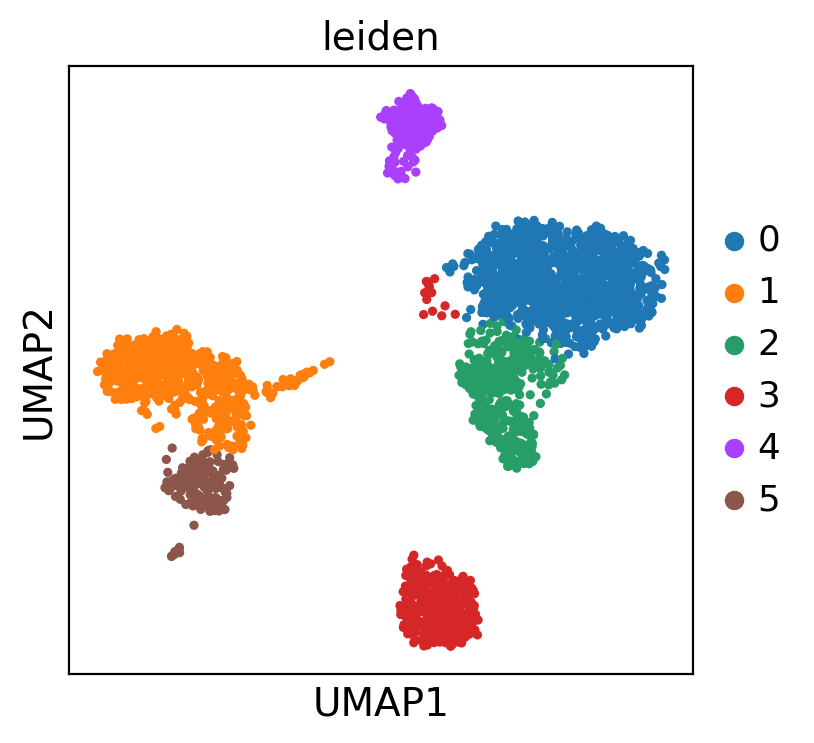

In [43]:
sc.pl.umap(adata, color=['leiden'])

## 12. Cluster별 marker gene 확인

`t-test`는 빠른 예시용입니다.  
실제 분석에서는 `wilcoxon`, pseudobulk DEG, sample-aware DEG 등을 같이 검토하는 것이 더 안전합니다.

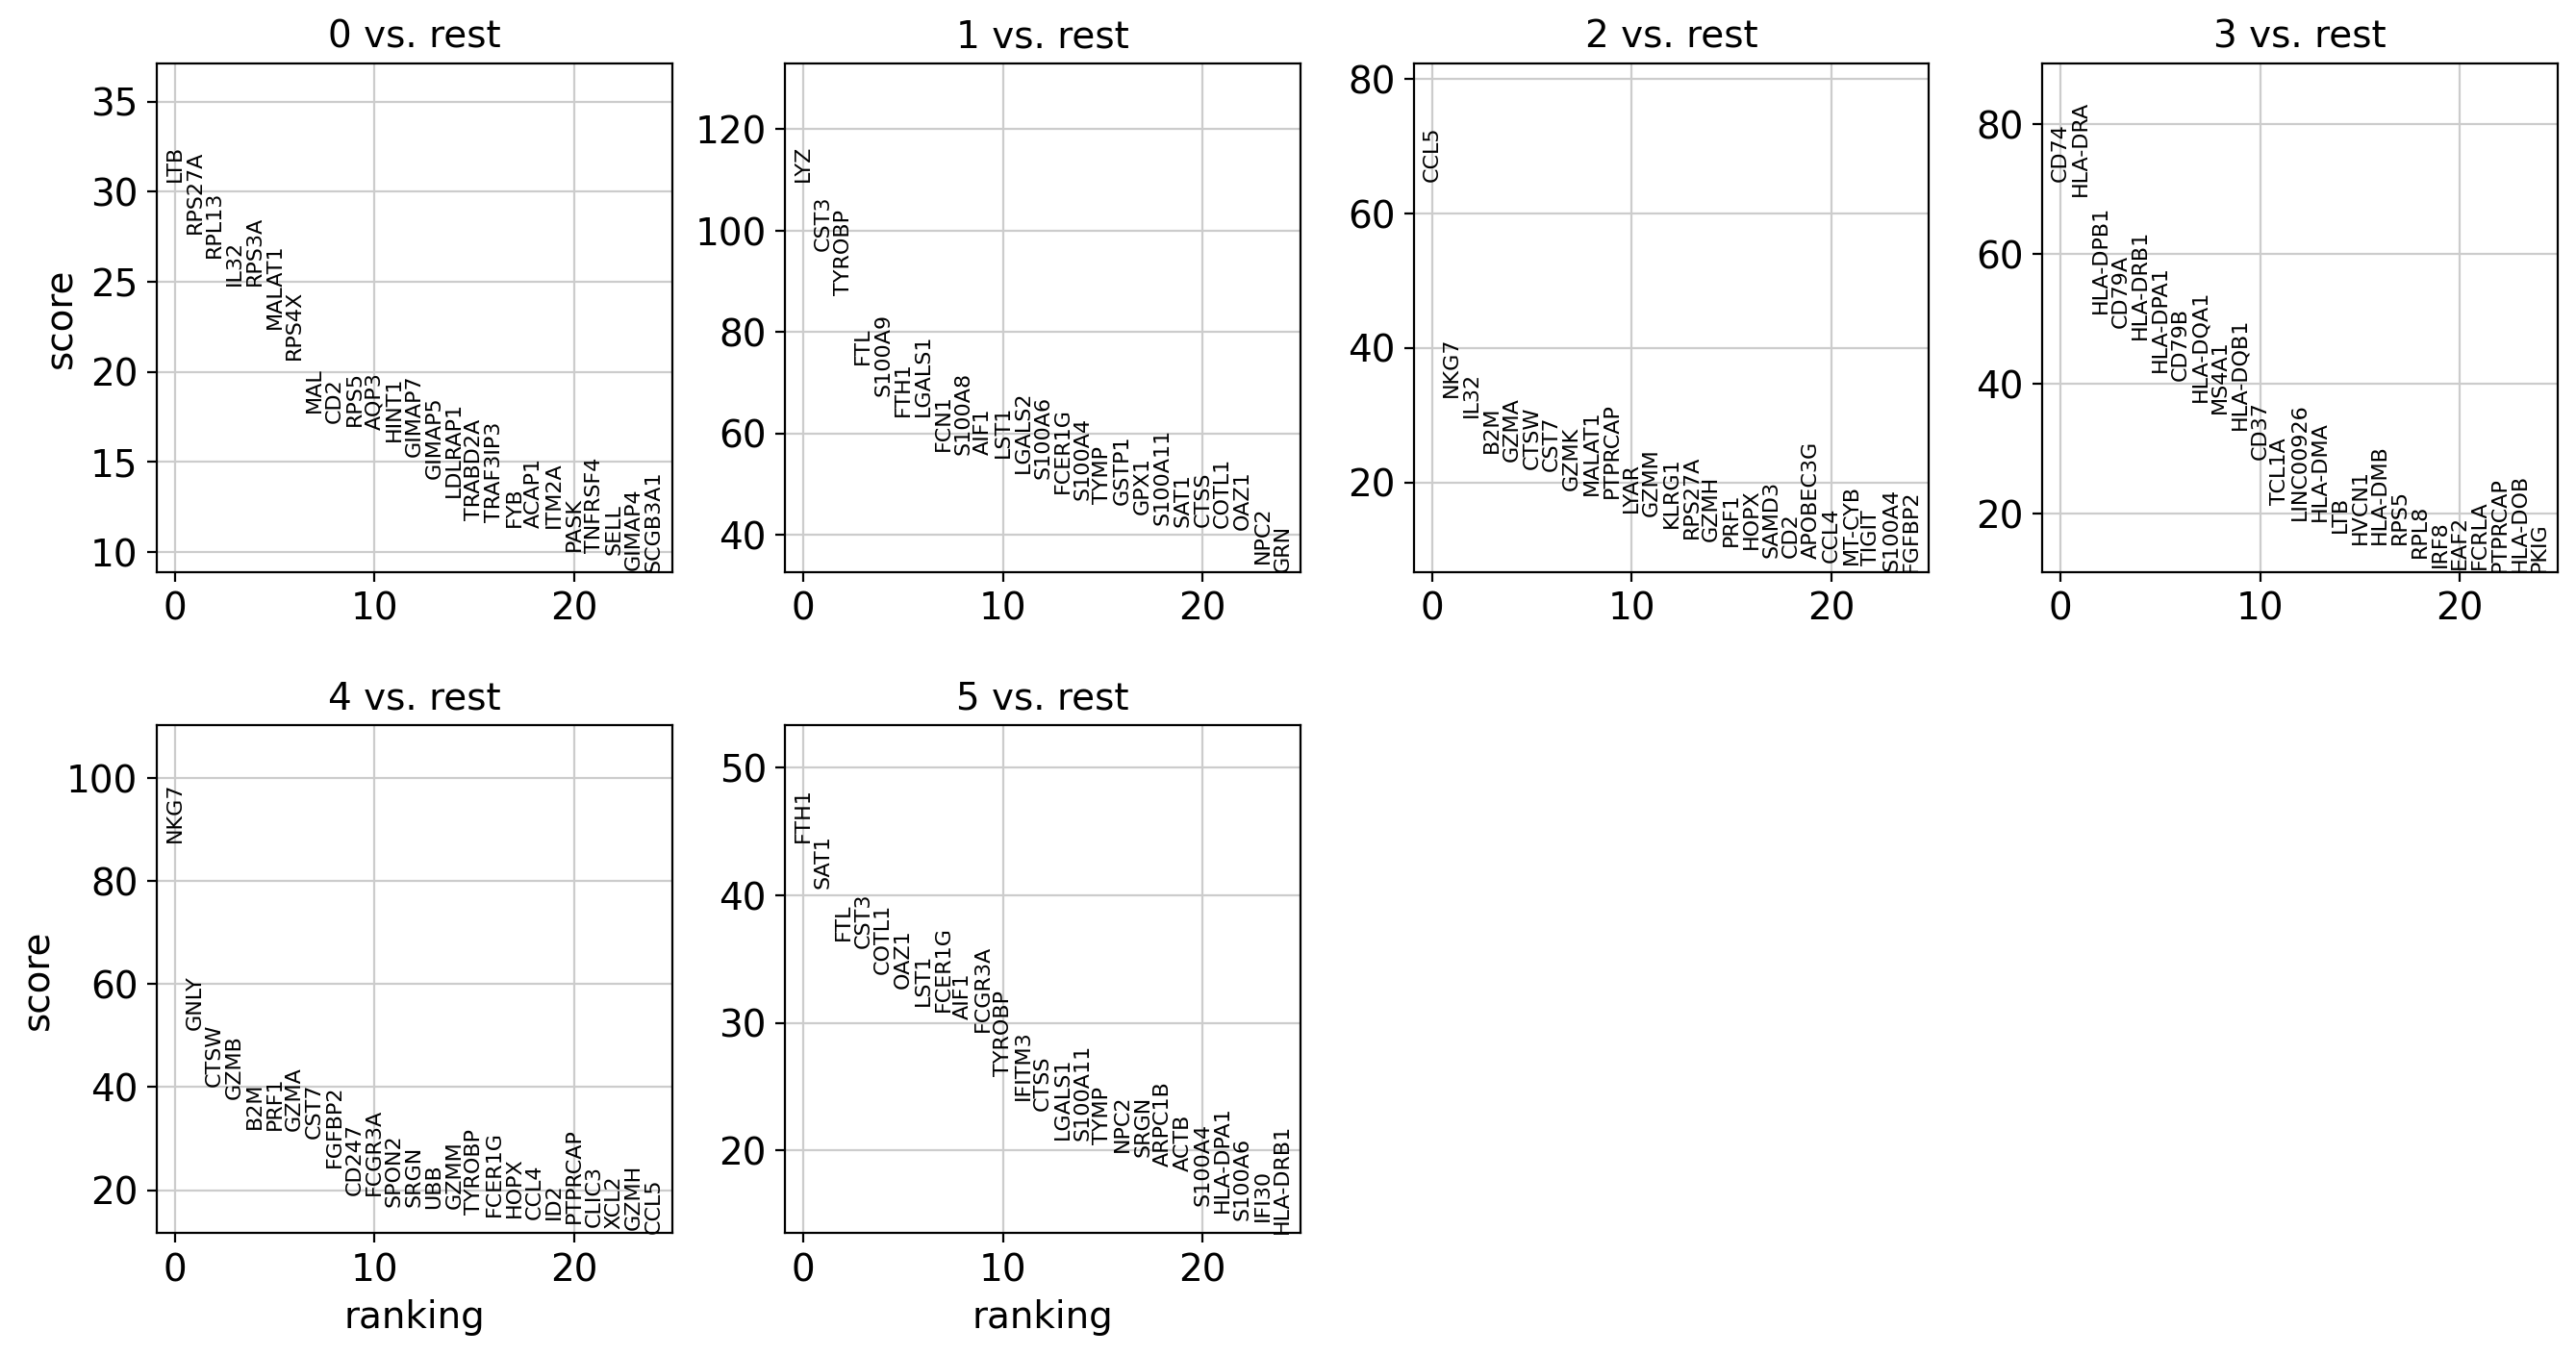

In [44]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    mask_var="highly_variable",
    method="t-test",
)

sc.pl.rank_genes_groups(
    adata,
    n_genes=25,
    sharey=False,
)

## 13. Marker 기반 cell type annotation

아래 marker set은 PBMC 예제용입니다.  
dataset이 바뀌면 marker gene도 반드시 다시 검토해야 합니다.

In [45]:
marker_genes = [
    # T / B / monocyte
    *["IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14"],

    # NK / monocyte / DC / platelet
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]

In [48]:
new_cluster_names = [
    "CD4 T",
    "CD14+ Monocytes",
    "CD8 T",
    "B",
    "NK",
    "FCGR3A+ Monocytes"
]

adata.rename_categories("leiden", new_cluster_names)

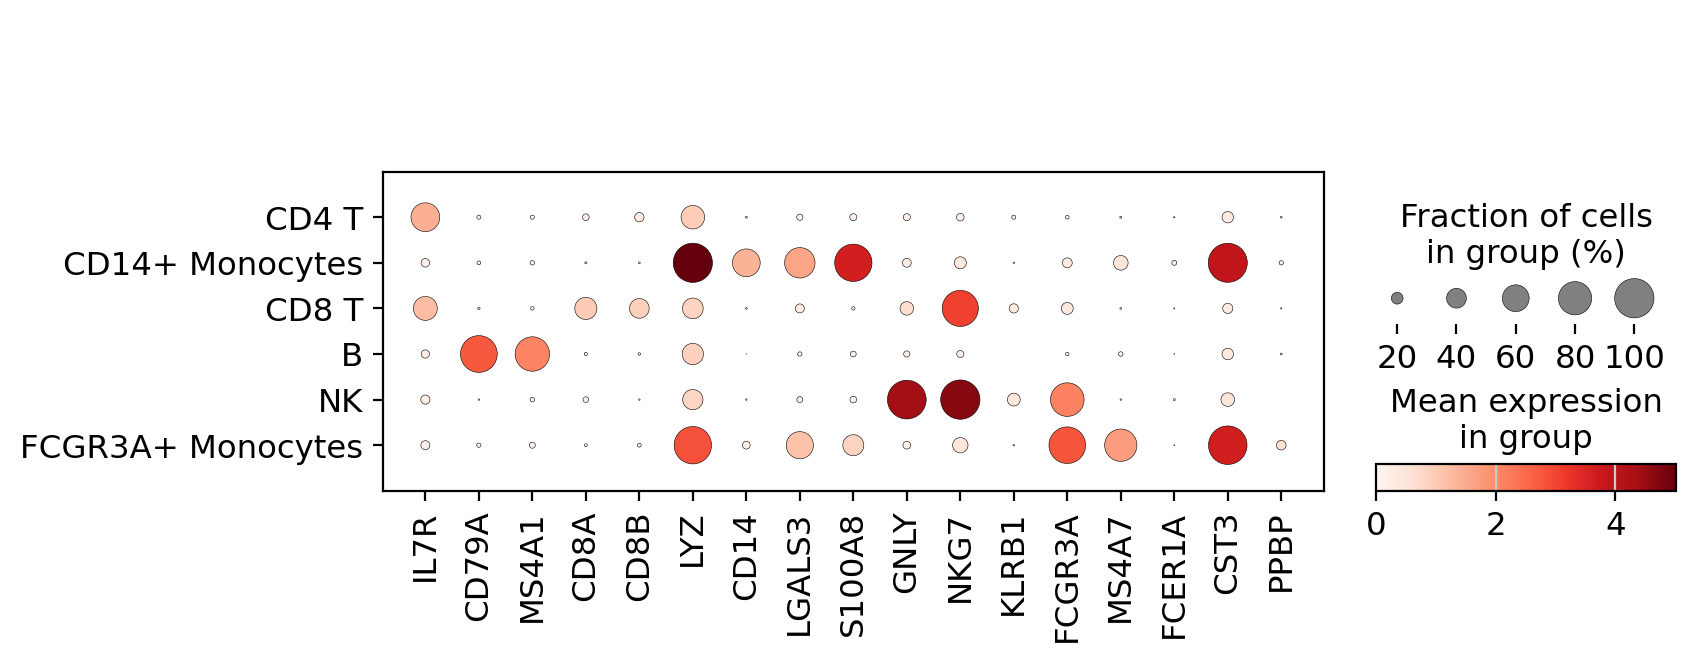

In [49]:
sc.pl.dotplot(adata, marker_genes, groupby='leiden')

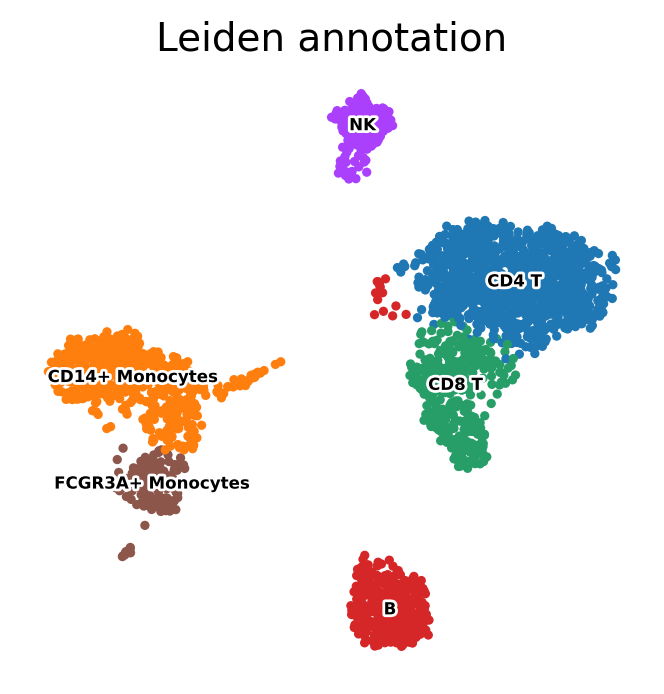

In [50]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    title="Leiden annotation",
    frameon=False,
    legend_fontsize=6,
    legend_fontoutline=2,
)

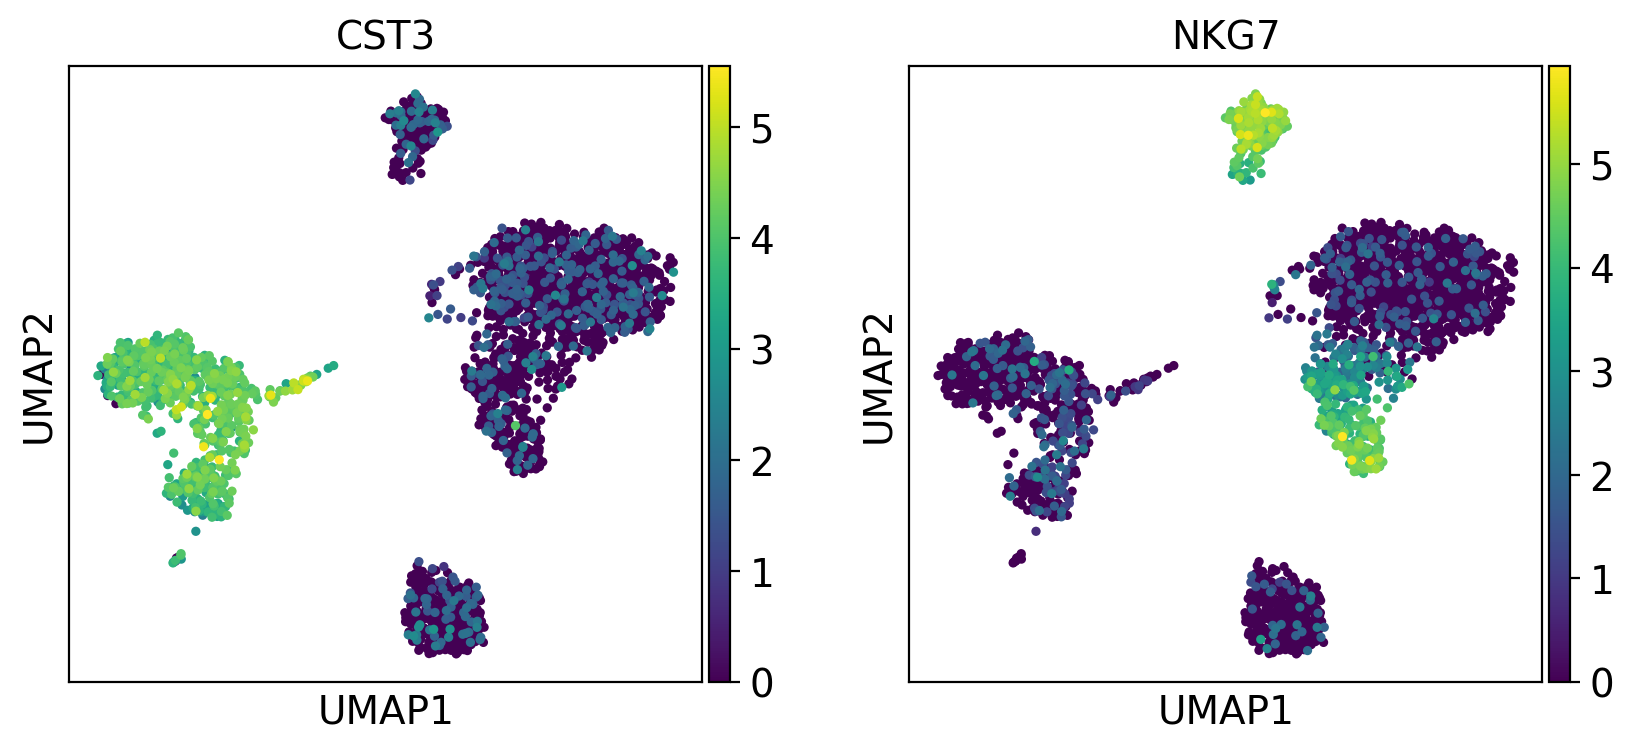

In [51]:
sc.pl.umap(
    adata,
    color=["CST3",'NKG7']
)

## 14. CellTypist annotation

CellTypist는 reference model 기반으로 cell type을 예측합니다.  
여기서는 PBMC에 맞는 `Healthy_COVID19_PBMC.pkl` 모델을 사용합니다.

`force_update=False`로 두면 매번 모델을 다시 다운로드하지 않습니다.  
최신 모델로 강제 갱신해야 할 때만 `True`로 바꾸면 됩니다.

In [52]:
import celltypist
from celltypist import models

In [32]:
# 실제 annotation에 사용할 PBMC model 다운로드
models.download_models(
    force_update=False,
    model="Healthy_COVID19_PBMC.pkl",
)

In [33]:
model = models.Model.load(model="Healthy_COVID19_PBMC.pkl")
model.cell_types

array(['ASDC', 'B_exhausted', 'B_immature', 'B_malignant', 'B_naive',
       'B_non-switched_memory', 'B_switched_memory', 'C1_CD16_mono',
       'CD14_mono', 'CD16_mono', 'CD4.CM', 'CD4.EM', 'CD4.IL22',
       'CD4.Naive', 'CD4.Prolif', 'CD4.Tfh', 'CD4.Th1', 'CD4.Th17',
       'CD4.Th2', 'CD8.EM', 'CD8.Naive', 'CD8.Prolif', 'CD8.TE',
       'CD83_CD14_mono', 'DC1', 'DC2', 'DC3', 'DC_prolif', 'HSC_CD38neg',
       'HSC_CD38pos', 'HSC_MK', 'HSC_erythroid', 'HSC_myeloid',
       'HSC_prolif', 'ILC1_3', 'ILC2', 'MAIT', 'Mono_prolif', 'NKT',
       'NK_16hi', 'NK_56hi', 'NK_prolif', 'Plasma_cell_IgA',
       'Plasma_cell_IgG', 'Plasma_cell_IgM', 'Plasmablast', 'Platelets',
       'RBC', 'Treg', 'gdT', 'pDC'], dtype=object)

In [53]:
predictions = celltypist.annotate(
    adata,
    model=model,
    majority_voting=True,
)

In [54]:
predictions.predicted_labels.head()

,predicted_labels,over_clustering,majority_voting
index,,,
AAACATACAACCAC-1,CD8.Naive,0,CD8.EM
AAACATTGAGCTAC-1,B_non-switched_memory,2,B_naive
AAACATTGATCAGC-1,CD4.CM,3,CD4.CM
AAACCGTGCTTCCG-1,CD16_mono,4,CD14_mono
AAACCGTGTATGCG-1,NK_16hi,6,NK_16hi


In [55]:
# CellTypist prediction 결과를 AnnData object에 반영
adata = predictions.to_adata()
adata

AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'predicted_labels', 'majority_voting', 'conf_score', 'over_clustering'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups', 'over_clustering', 'majority_voting_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obs

## 15. Leiden annotation과 CellTypist 결과 비교

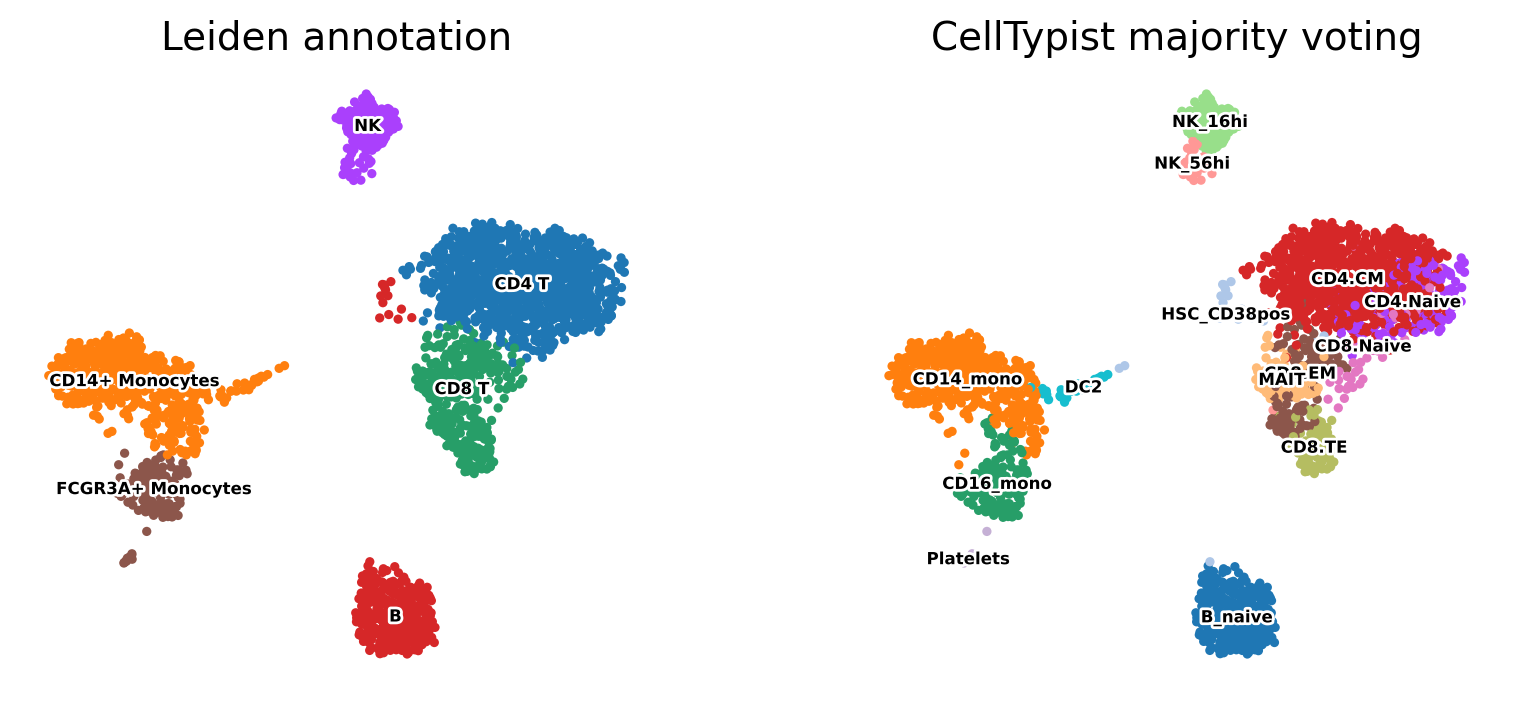

In [56]:
sc.pl.umap(
    adata,
    color=["leiden", "majority_voting"],
    legend_loc="on data",
    title=["Leiden annotation", "CellTypist majority voting"],
    frameon=False,
    legend_fontsize=6,
    legend_fontoutline=2,
)